# BasketIQ — Step 3: RFM Analysis (Customer Segmentation)

**Goal of this notebook:** score every customer on three dimensions and use them to segment customers into meaningful groups (loyal, at-risk, new, high-value, etc.).

**RFM** stands for:
- **Recency (R)** — how many days ago did the customer last purchase? (lower = better, means they bought recently)
- **Frequency (F)** — how many separate orders has the customer placed? (higher = better)
- **Monetary (M)** — how much money has the customer spent in total? (higher = better)

This is one of the most widely used techniques in retail/marketing analytics because it turns raw transactions into an actionable customer profile, without needing any machine learning.

## 1. Import libraries and load the cleaned data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import datetime as dt

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
PROCESSED_DATA_PATH = Path('..') / 'data' / 'processed' / 'online_retail_clean.csv'

df = pd.read_csv(PROCESSED_DATA_PATH, parse_dates=['InvoiceDate'])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 2. Set a reference date

"Recency" needs a fixed point in time to measure "days since last purchase" from. Since this is historical data (not live), we use **one day after the last transaction in the dataset** as our reference "today". In a real, live system you'd use the actual current date instead.

In [3]:
reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
print('Reference date used for Recency calculation:', reference_date)

Reference date used for Recency calculation: 2011-12-10 12:50:00


## 3. Calculate R, F, and M per customer

We group all transactions by `CustomerID` and compute:
- **Recency** = (reference_date - date of their most recent invoice) in days
- **Frequency** = number of distinct invoices (orders) they placed
- **Monetary** = sum of `TotalPrice` across all their transactions

In [4]:
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [5]:
# Quick look at the distribution of each metric
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


## 4. Score each metric from 1 to 5

Raw numbers (e.g. "Recency = 45 days", "Monetary = 2,340") are hard to compare across customers. So we convert each metric into a **score from 1 (worst) to 5 (best)** using quantiles — each score band contains roughly 20% of customers.

Important detail: for **Recency**, a *smaller* number of days is better (bought recently), so the scoring direction is reversed compared to Frequency and Monetary, where a *bigger* number is better.

In [6]:
# pd.qcut splits values into 5 equal-sized groups (quintiles) and labels them 1-5
# For Recency: label 5 = most recent (smallest days), label 1 = least recent (largest days) -> labels reversed
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)

# For Frequency and Monetary: label 5 = highest value, label 1 = lowest value
# rank(method='first') breaks ties before qcut, since many customers can share the same Frequency value
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

# Combine the three scores into one string, e.g. '555' = best possible customer, '111' = worst
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,5,115
1,12347,2,7,4310.00,5,5,5,555
2,12348,75,4,1797.24,2,4,4,244
3,12349,19,1,1757.55,4,1,4,414
4,12350,310,1,334.40,1,1,2,112


## 5. Translate scores into human-readable segments

A 3-digit score like `'535'` is precise but not intuitive. We map common score patterns to plain-language segment names that a marketing team could act on directly.

In [7]:
def segment_customer(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'          # bought recently, often, and spend a lot
    elif r >= 4 and f >= 3:
        return 'Loyal Customers'    # recent and frequent, though not top spenders
    elif r >= 4 and f <= 2:
        return 'New Customers'      # bought recently but not often yet
    elif r <= 2 and f >= 4:
        return 'At Risk'            # used to buy a lot, but haven't come back recently
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'               # low on every metric
    else:
        return 'Needs Attention'    # doesn't clearly fit the other buckets

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,1,77183.60,1,1,5,115,Needs Attention
1,12347,2,7,4310.00,5,5,5,555,Champions
2,12348,75,4,1797.24,2,4,4,244,At Risk
3,12349,19,1,1757.55,4,1,4,414,New Customers
4,12350,310,1,334.40,1,1,2,112,Lost


## 6. Visualize the segments

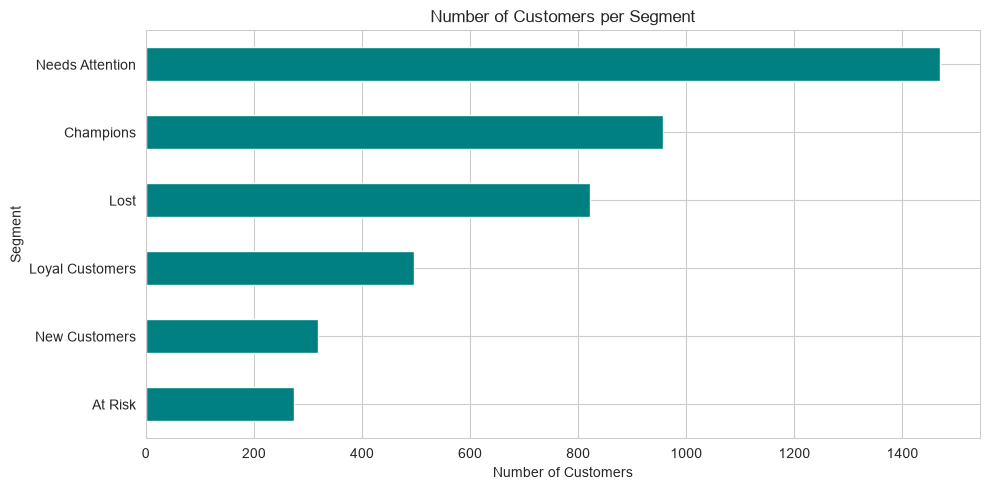

In [8]:
# How many customers fall into each segment
segment_counts = rfm['Segment'].value_counts()

fig, ax = plt.subplots()
segment_counts.sort_values().plot(kind='barh', ax=ax, color='teal')
ax.set_title('Number of Customers per Segment')
ax.set_xlabel('Number of Customers')
plt.tight_layout()
plt.show()

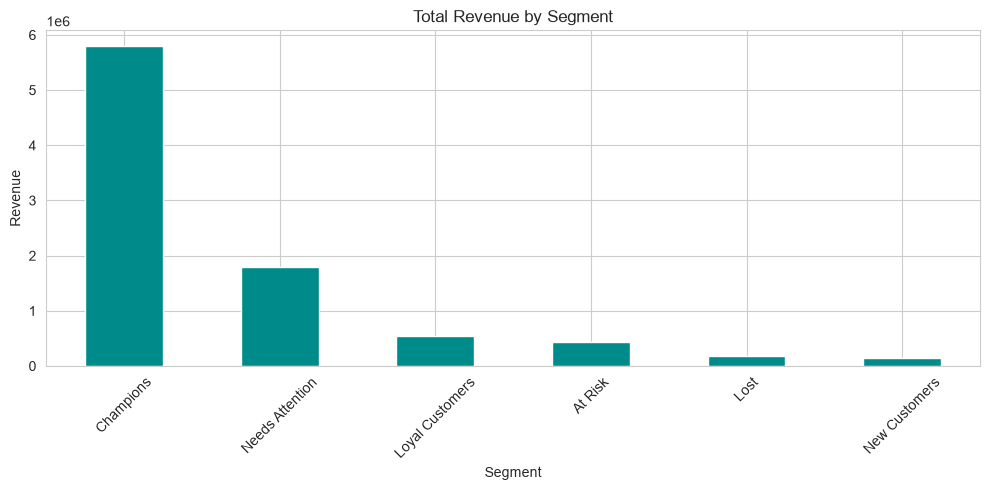

In [9]:
# How much total revenue each segment is responsible for
# This often reveals that a small segment (e.g. Champions) drives a large share of revenue
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
segment_revenue.plot(kind='bar', ax=ax, color='darkcyan')
ax.set_title('Total Revenue by Segment')
ax.set_ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Save the RFM table

We save this per-customer table separately from the transaction-level data, since it will be reused directly in the next notebook (clustering) instead of recomputing it from scratch.

In [10]:
RFM_OUTPUT_PATH = Path('..') / 'data' / 'processed' / 'rfm_table.csv'

rfm.to_csv(RFM_OUTPUT_PATH, index=False)
print(f'Saved RFM table to: {RFM_OUTPUT_PATH.resolve()}')

Saved RFM table to: D:\New folder\BasketIQ\data\processed\rfm_table.csv
